In [2]:
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


# PRIMERA PARTE DEL INFORME

In [22]:
# 1.- IMPORTAR LIBRERIAS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller


In [4]:
# 2.- SIMULACION DE LOS DATOS
np.random.seed(42)
n = 100
fechas = pd.date_range(start='2020-01-01', periods=n, freq='W')
media = 100
ruido = np.random.normal(loc=media, scale=5, size=n)




In [7]:
# 3.- DATAFRAME
df = pd.DataFrame({'fecha': fechas, 'ventas': ruido})


Analisis Exploratorio de Los Datos

In [9]:
df.head()

,fecha,ventas
0,2020-01-05,102.483571
1,2020-01-12,99.308678
2,2020-01-19,103.238443
3,2020-01-26,107.615149
4,2020-02-02,98.829233


In [10]:
df.describe()

,fecha,ventas
count,100,100.000000
mean,2020-12-16 12:00:00,99.480767
min,2020-01-05 00:00:00,86.901274
25%,2020-06-26 06:00:00,96.995472
50%,2020-12-16 12:00:00,99.365219
75%,2021-06-07 18:00:00,102.029760
max,2021-11-28 00:00:00,109.261391
std,NaN,4.540842


In [11]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
95,False
96,False
97,False
98,False


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   fecha   100 non-null    datetime64[ns]
 1   ventas  100 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 1.7 KB


In [34]:
df.shape

(100, 2)

In [35]:
df.columns

Index(['fecha', 'ventas'], dtype='object')

In [37]:
df['fecha'].min()


Timestamp('2020-01-05 00:00:00')

In [38]:
df['fecha'].max()

Timestamp('2021-11-28 00:00:00')

In [17]:
#4.- Serie de tiempo estacionaria
df_estacionaria = df[['fecha', 'ventas']]

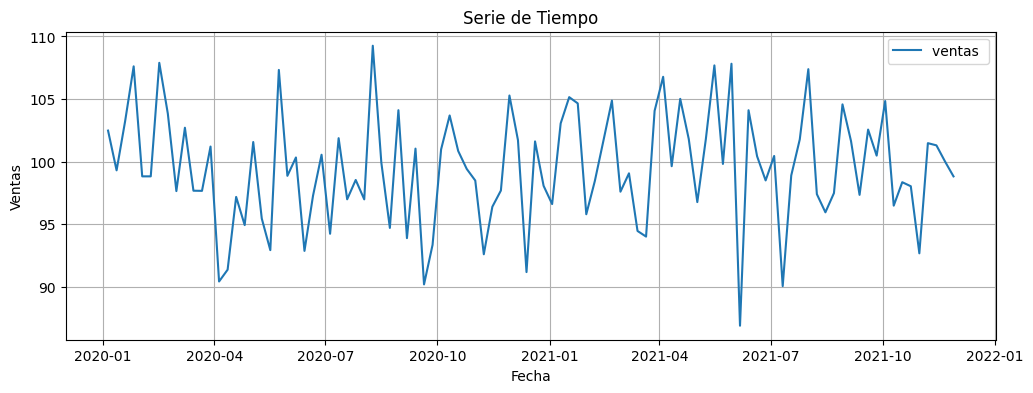

In [21]:
# 5.-Media y Desviacion Movil

df_estacionaria['media_movil'] = df_estacionaria['ventas'].rolling(window=10).mean()
df_estacionaria['desviacion_movil'] = df_estacionaria['ventas'].rolling(window=10).std()

#6.- Muestra de la serie

plt.figure(figsize=(12, 4))
plt.plot(df_estacionaria['fecha'], df_estacionaria['ventas'], label='ventas ')
plt.title('Serie de Tiempo')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.legend()
plt.show()


In [24]:
#7.- Comprobación estadistico de la serie estacionaria
resumen_estadistico = pd.DataFrame({
    'Indicador': ['Media', 'Moda', 'Desviación estándar', 'Varianza'],
    'Valor': [
        df_estacionaria['ventas'].mean(),
        df_estacionaria['ventas'].mode().iloc[0],
        df_estacionaria['ventas'].std(),
        df_estacionaria['ventas'].var()
    ]
})

print(resumen_estadistico)

             Indicador      Valor
0                Media  99.480767
1                 Moda  86.901274
2  Desviación estándar   4.540842
3             Varianza  20.619247


**Análisis estadisticos Descriptivos**

Los indicadores estadísticos muestran que la serie de ventas tiene un comportamiento estable. La media de 99,48 indica que las ventas se mantienen cercanas a las 100 unidades en promedio. La desviación estándar de 4,54 refleja que los valores no se alejan demasiado de ese promedio, mientras que la varianza de 20,62 confirma que la dispersión de los datos es moderada.

Aunque la moda es de 86,90, este valor tiene menor peso interpretativo debido a que la serie fue generada con datos continuos y aleatorios. En general, los resultados permiten concluir que las ventas fluctúan de manera controlada alrededor de una media constante, lo que respalda que la serie presenta un comportamiento estacionario.

In [25]:
#8.- Comprobacion con bloques de tiempo
df_estacionaria['bloque'] = pd.cut(
    df_estacionaria.index,
    bins=4,
    labels=['Bloque 1', 'Bloque 2', 'Bloque 3', 'Bloque 4']
)

resumen_bloques = df_estacionaria.groupby('bloque')['ventas'].agg(
    media='mean',
    moda=lambda x: x.mode().iloc[0],
    desviacion_estandar='std',
    varianza='var'
)

print(resumen_bloques)

               media       moda  desviacion_estandar   varianza
bloque                                                         
Bloque 1   99.182460  90.433599             4.782765  22.874844
Bloque 2   98.562801  90.201649             4.628185  21.420098
Bloque 3  100.530470  86.901274             4.935232  24.356512
Bloque 4   99.647339  90.062155             3.775683  14.255785


/tmp/ipykernel_1684/3119541942.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  resumen_bloques = df_estacionaria.groupby('bloque')['ventas'].agg(


In [23]:
# 9.- Prueba ADF
resultado = adfuller(df_estacionaria['ventas'])

print('Estadístico ADF:', resultado[0])
print('p-value:', resultado[1])
print('Valores críticos:', resultado[4])

if resultado[1] < 0.05:
    print("Conclusión: La serie es estacionaria")
else:
    print("Conclusión: La serie NO es estacionaria")

Estadístico ADF: -10.084425913669712
p-value: 1.1655044784188833e-17
Valores críticos: {'1%': np.float64(-3.498198082189098), '5%': np.float64(-2.891208211860468), '10%': np.float64(-2.5825959973472097)}
Conclusión: La serie es estacionaria


# Interpretación del Resultado

**La serie de tiempo simulada presenta un comportamiento estacionario, ya que los valores de ventas fluctúan alrededor de una media constante cercana a 100 unidades. Al analizar el gráfico, no se observa una tendencia creciente ni decreciente, sino variaciones aleatorias propias del ruido incorporado en la simulación. Además, la desviación estándar y la varianza permiten evidenciar que la dispersión de los datos se mantiene relativamente estable en el tiempo.**

**El análisis mediante media móvil y desviación móvil refuerza esta conclusión, ya que ambos indicadores no presentan cambios bruscos ni patrones persistentes de aumento o disminución. Finalmente, la prueba ADF permite validar estadísticamente la estacionariedad de la serie, dado que un valor p menor a 0,05 indica que se rechaza la hipótesis de no estacionariedad. Por lo tanto, la serie puede considerarse estacionaria y es adecuada para aplicar un modelo ARIMA con diferenciación igual a cero.**


# SEGUNDA PARTE DEL INFORME

**IMPLEMENTACIÓN Y GRÁFICO DEL MODELO ARIMA**

In [27]:
#10.- Implementar MODELO ARIMA

from statsmodels.tsa.arima.model import ARIMA

# Definición de la serie de tiempo

serie = df_estacionaria['ventas']

# Crear modelo ARIMA
# Como la serie es estacionaria, usamos d = 0
modelo_arima = ARIMA(serie, order=(1, 0, 1))

# Ajustar el modelo
resultado_arima = modelo_arima.fit()

# Mostrar resumen del modelo
print(resultado_arima.summary())

                               SARIMAX Results                                
Dep. Variable:                 ventas   No. Observations:                  100
Model:                 ARIMA(1, 0, 1)   Log Likelihood                -292.072
Date:                Sun, 26 Apr 2026   AIC                            592.144
Time:                        02:44:06   BIC                            602.565
Sample:                             0   HQIC                           596.361
                                - 100                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         99.4403      0.331    300.660      0.000      98.792     100.089
ar.L1          0.9584      0.095     10.086      0.000       0.772       1.145
ma.L1         -0.9998      5.764     -0.173      0.8

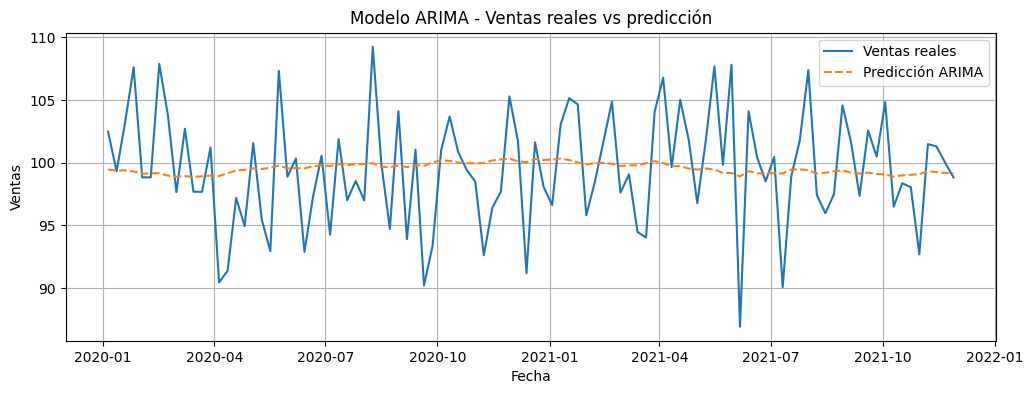

In [29]:
#11.- Graficar MODELO ARIMA

df_estacionaria['prediccion_arima'] = resultado_arima.fittedvalues

plt.figure(figsize=(12, 4))

plt.plot(
    df_estacionaria['fecha'],
    df_estacionaria['ventas'],
    label='Ventas reales'
)

plt.plot(
    df_estacionaria['fecha'],
    df_estacionaria['prediccion_arima'],
    label='Predicción ARIMA',
    linestyle='--'
)

plt.title('Modelo ARIMA - Ventas reales vs predicción')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.legend()
plt.show()

In [30]:
#12.- Pronostico futuro con ARIMA

n_periodos = 10

pronostico = resultado_arima.forecast(steps=n_periodos)

fechas_futuras = pd.date_range(
    start=df_estacionaria['fecha'].iloc[-1] + pd.Timedelta(weeks=1),
    periods=n_periodos,
    freq='W'
)

df_pronostico = pd.DataFrame({
    'fecha': fechas_futuras,
    'pronostico_ventas': pronostico.values
})

print(df_pronostico)

       fecha  pronostico_ventas
0 2021-12-05          99.191730
1 2021-12-12          99.202078
2 2021-12-19          99.211996
3 2021-12-26          99.221501
4 2022-01-02          99.230610
5 2022-01-09          99.239339
6 2022-01-16          99.247706
7 2022-01-23          99.255724
8 2022-01-30          99.263408
9 2022-02-06          99.270772


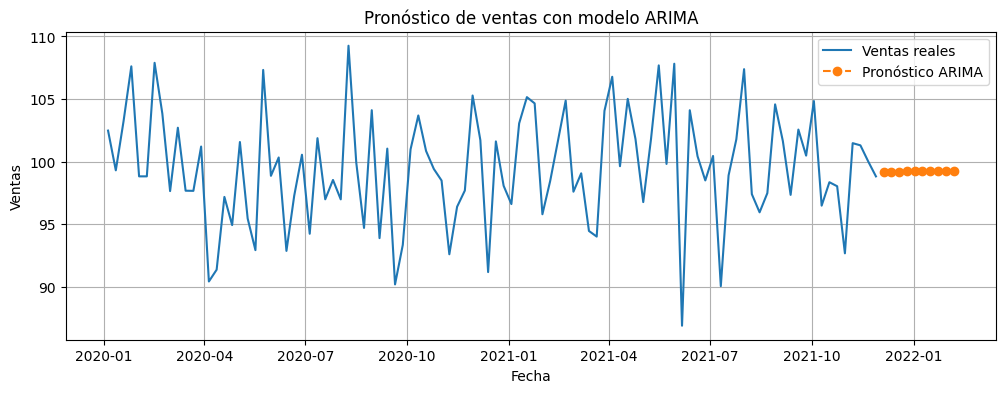

In [31]:
# 13.-Gráfico de Ventas Reales y Futuras

plt.figure(figsize=(12, 4))

plt.plot(
    df_estacionaria['fecha'],
    df_estacionaria['ventas'],
    label='Ventas reales'
)

plt.plot(
    df_pronostico['fecha'],
    df_pronostico['pronostico_ventas'],
    label='Pronóstico ARIMA',
    linestyle='--',
    marker='o'
)

plt.title('Pronóstico de ventas con modelo ARIMA')
plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.grid(True)
plt.legend()
plt.show()

# Interpretación del Resultado

**Se implementó un modelo ARIMA(1,0,1) sobre la serie de tiempo de ventas simuladas. Este modelo fue seleccionado debido a que previamente se comprobó que la serie era estacionaria, por lo que no fue necesario aplicar diferenciación y el parámetro d se estableció en 0.**

**Al comparar los valores reales con los valores ajustados por el modelo ARIMA, se observa que el modelo intenta representar el comportamiento general de la serie. Sin embargo, debido a que los datos fueron simulados con ruido aleatorio alrededor de una media constante, las predicciones tienden a mantenerse cercanas al promedio histórico.**

**El pronóstico futuro mantiene un comportamiento estable, sin evidenciar aumentos o disminuciones sostenidas. Esto es coherente con una serie estacionaria, ya que no presenta tendencia marcada ni cambios importantes en su variabilidad. En consecuencia, el modelo ARIMA permite proyectar valores futuros consistentes con el comportamiento histórico de las ventas.**

**¿ Porque se utilizó en ARIMA la nomenclatura (1,0,1) ?**

El modelo ARIMA(1,0,1) fue utilizado porque la serie de tiempo es estacionaria.

* **El valor p=1 indica que se considera el valor anterior de la serie.**

* **El valor d=0 significa que no se aplicó diferenciación, ya que la serie no presenta tendencia y mantiene estabilidad en su media y varianza.**

* **El valor q=1 indica que se incorpora el error del periodo anterior para mejorar el ajuste del modelo.**

Por esta razón, ARIMA(1,0,1) resulta adecuado como modelo inicial para analizar y pronosticar esta serie de ventas simuladas.

# TERCERA PARTE DEL INFORME

**Evaluación de residuos del Modelo Implementado**

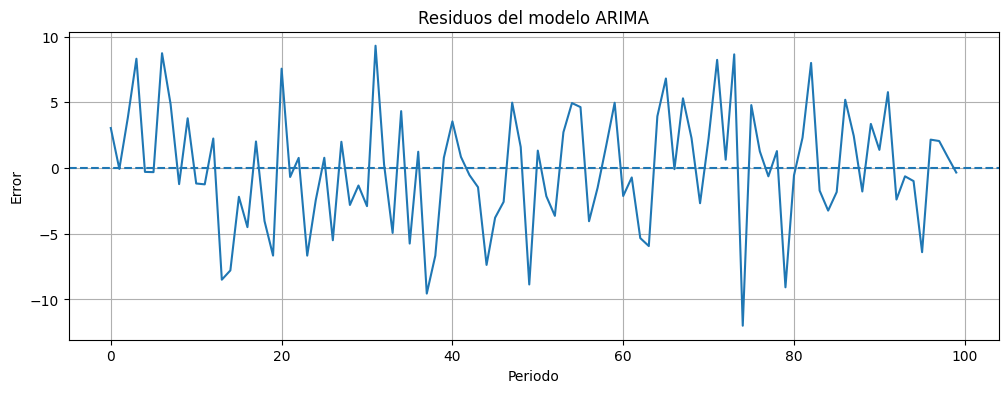

In [32]:
# 14.- EVALUACIÓN DE RESIDUOS DEL MODELO ARIMA

residuos = resultado_arima.resid

plt.figure(figsize=(12,4))
plt.plot(residuos)
plt.axhline(0, linestyle='--')
plt.title('Residuos del modelo ARIMA')
plt.xlabel('Periodo')
plt.ylabel('Error')
plt.grid(True)
plt.show()

In [33]:
# 13.- EVALUACIÓN DEL RENDIMIENTO DEL MODELO

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Valores reales
y_real = df_estacionaria['ventas']

# Valores predichos por ARIMA
y_pred = df_estacionaria['prediccion_arima']

# Métricas de evaluación
mae = mean_absolute_error(y_real, y_pred)
mse = mean_squared_error(y_real, y_pred)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((y_real - y_pred) / y_real)) * 100

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE: 3.556373354555866
MSE: 20.161144360964613
RMSE: 4.490116297042273
MAPE: 3.601309532575266


# Interpretacion de los Residuos

| Métrica | Interpretación                                                 |
| ------- | -------------------------------------------------------------- |
| MAE     | En promedio, cuánto se equivoca el modelo en unidades de venta |
| MSE     | Penaliza más los errores grandes                               |
| RMSE    | Error promedio aproximado en la misma escala de las ventas     |
| MAPE    | Porcentaje promedio de error del modelo                        |


**El modelo ARIMA fue evaluado considerando sus supuestos y su rendimiento. El principal supuesto es que la serie sea estacionaria. En este caso, se cumple, ya que la serie presenta una media estable, una variabilidad controlada y la prueba ADF confirma su estacionariedad. Por eso se utilizó un modelo ARIMA(1,0,1), con d=0, sin aplicar diferenciación.**

**También se revisaron los residuos del modelo, los cuales deberían comportarse como ruido blanco, es decir, sin patrones claros ni tendencia. Si los residuos fluctúan alrededor de cero, se puede considerar que el modelo captura adecuadamente el comportamiento general de la serie.**

**En cuanto al rendimiento, se pueden utilizar métricas como MAE, MSE, RMSE y MAPE para comparar los valores reales con las predicciones. En este caso, el modelo entrega un rendimiento razonable, ya que las predicciones se mantienen cercanas al promedio histórico. Sin embargo, como los datos son simulados y no presentan tendencia ni estacionalidad, el modelo funciona principalmente como una herramienta demostrativa para pronosticar una serie estacionaria simple.**